# cancer.csv 기반 PCA 차원 축소 실습

## 실습 목표

이 노트북은 기존 실습 데이터인 `cancer.csv`를 대상으로 **PCA(Principal Component Analysis, 주성분 분석)** 를 이용해 고차원 데이터를 저차원으로 축소하는 전 과정을 실습합니다.

강의자료의 흐름에 맞추어 다음 내용을 포함합니다.

1. `pandas`로 실제 데이터 로딩 및 구조 확인
2. `Series`, `DataFrame`, 인덱싱, 결측값, 기술통계 확인
3. 머신러닝 입력 데이터 `X`와 정답 데이터 `y` 분리
4. PCA 전 표준화가 필요한 이유 확인
5. PCA로 2차원 축소 및 시각화
6. 설명분산비와 누적 설명분산비로 적절한 차원 수 판단
7. 주성분 로딩(loadings)을 이용한 변수 기여도 해석
8. 원본 특성, PCA 2차원, PCA 5차원, PCA 95% 보존 모델 성능 비교

> 핵심 흐름: **DataFrame → 전처리 → 표준화 → PCA → 시각화/해석 → 모델 적용**

## 0. 실습 환경 준비

필요한 라이브러리를 불러옵니다.

- `pandas`, `numpy`: 데이터 처리
- `matplotlib`: 시각화
- `sklearn`: 표준화, PCA, 모델 학습 및 평가

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print('준비 완료')

준비 완료


## 1. 데이터 로딩

`cancer.csv`는 유방암 진단 데이터입니다.

- `type`: 진단 결과, 정답 레이블
- 나머지 30개 컬럼: 세포 핵 이미지에서 계산된 수치형 특성

노트북과 `cancer.csv`가 같은 폴더에 있거나, `data/cancer.csv` 위치에 있으면 자동으로 읽도록 구성했습니다.

In [2]:
def find_data_file(filename):
    candidates = [
        Path(filename),
        Path('data') / filename,
        Path('/mnt/data') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f'{filename} 파일을 찾을 수 없습니다. 노트북과 같은 폴더 또는 data 폴더에 파일을 두세요.'
    )

DATA_PATH = find_data_file('cancer.csv')
print('데이터 경로:', DATA_PATH)

cancer = pd.read_csv(DATA_PATH)
cancer.head()

데이터 경로: data\cancer.csv


,type,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,malignant,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,malignant,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,malignant,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,malignant,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


## 2. DataFrame 구조 확인

강의자료의 `DataFrame` 핵심 속성인 `index`, `columns`, `values`, `shape`, `dtypes`를 확인합니다.

In [3]:
print('DataFrame 타입:', type(cancer))
print('행/열 크기:', cancer.shape)
print('행 인덱스 예:', cancer.index[:5].tolist())
print('컬럼 수:', len(cancer.columns))

cancer.info()

DataFrame 타입: <class 'pandas.core.frame.DataFrame'>
행/열 크기: (569, 31)
행 인덱스 예: [0, 1, 2, 3, 4]
컬럼 수: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   type                     569 non-null    object 
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 n

In [4]:
# 컬럼명 확인
cancer.columns.tolist()

['type',
 'mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

### 실습 포인트

`cancer.csv`는 총 31개 컬럼으로 구성되어 있습니다.

- 1개 정답 컬럼: `type`
- 30개 입력 특성 컬럼: `mean radius`, `mean texture`, ...

PCA는 **수치형 입력 특성**에 적용해야 하므로, 정답 컬럼인 `type`은 PCA 대상에서 제외합니다.

## 3. Series와 DataFrame 기본 조작

`DataFrame`에서 하나의 열을 선택하면 `Series`가 됩니다.

In [5]:
# 하나의 열 선택: Series
mean_radius = cancer['mean radius']

print('mean_radius 타입:', type(mean_radius))
print('Series 이름:', mean_radius.name)
print('Series 길이:', len(mean_radius))

mean_radius.head()

mean_radius 타입: <class 'pandas.core.series.Series'>
Series 이름: mean radius
Series 길이: 569


0   17.9900
1   20.5700
2   19.6900
3   11.4200
4   20.2900
Name: mean radius, dtype: float64

In [6]:
# 여러 열 선택: DataFrame
basic_cols = ['type', 'mean radius', 'mean texture', 'mean perimeter', 'mean area']
basic_df = cancer[basic_cols]

print('basic_df 타입:', type(basic_df))
basic_df.head()

basic_df 타입: <class 'pandas.core.frame.DataFrame'>


,type,mean radius,mean texture,mean perimeter,mean area
0,malignant,17.9900,10.3800,122.8000,1001.0000
1,malignant,20.5700,17.7700,132.9000,1326.0000
2,malignant,19.6900,21.2500,130.0000,1203.0000
3,malignant,11.4200,20.3800,77.5800,386.1000
4,malignant,20.2900,14.3400,135.1000,1297.0000


## 4. loc, iloc 인덱싱 실습

- `loc`: 인덱스 이름과 컬럼 이름 기반 선택
- `iloc`: 정수 위치 기반 선택

In [7]:
# loc: 행 인덱스와 컬럼명으로 선택
cancer.loc[0:4, ['type', 'mean radius', 'mean texture']]

,type,mean radius,mean texture
0,malignant,17.9900,10.3800
1,malignant,20.5700,17.7700
2,malignant,19.6900,21.2500
3,malignant,11.4200,20.3800
4,malignant,20.2900,14.3400


In [8]:
# iloc: 정수 위치로 선택
# 앞 5행, 앞 5열
cancer.iloc[:5, :5]

,type,mean radius,mean texture,mean perimeter,mean area
0,malignant,17.9900,10.3800,122.8000,1001.0000
1,malignant,20.5700,17.7700,132.9000,1326.0000
2,malignant,19.6900,21.2500,130.0000,1203.0000
3,malignant,11.4200,20.3800,77.5800,386.1000
4,malignant,20.2900,14.3400,135.1000,1297.0000


In [9]:
# Boolean indexing: mean radius가 상위 10% 이상인 행만 선택
threshold = cancer['mean radius'].quantile(0.90)
large_radius = cancer.loc[cancer['mean radius'] >= threshold, ['type', 'mean radius', 'mean area']]

print('기준값:', threshold)
print('선택된 행 수:', len(large_radius))
large_radius.head()

기준값: 19.53
선택된 행 수: 58


,type,mean radius,mean area
1,malignant,20.5700,1326.0000
2,malignant,19.6900,1203.0000
4,malignant,20.2900,1297.0000
18,malignant,19.8100,1260.0000
23,malignant,21.1600,1404.0000


## 5. 정답 레이블 분포 확인

`value_counts()`를 사용하면 범주형 값의 빈도를 빠르게 확인할 수 있습니다.

In [10]:
y = cancer['type']

type_counts = y.value_counts()
type_ratio = y.value_counts(normalize=True).rename('ratio')

diagnosis_summary = pd.concat([type_counts.rename('count'), type_ratio], axis=1)
diagnosis_summary

,count,ratio
type,,
benign,357,0.6274
malignant,212,0.3726


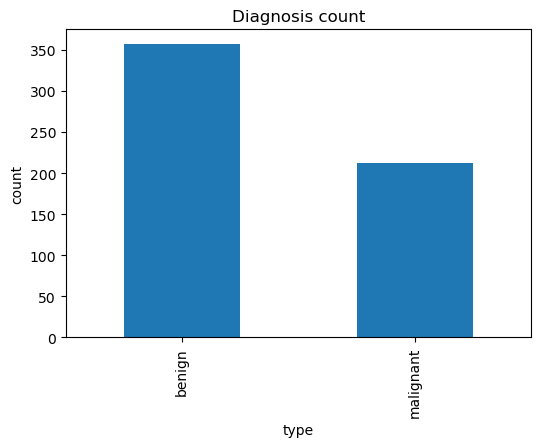

In [11]:
ax = type_counts.plot(kind='bar', figsize=(6, 4), title='Diagnosis count')
ax.set_xlabel('type')
ax.set_ylabel('count')
plt.show()

## 6. 결측값 확인

강의자료의 `isnull`, `notnull`, `dropna`, `fillna` 개념과 연결됩니다.

PCA는 결측값이 있으면 바로 적용하기 어렵기 때문에, 먼저 결측값을 확인해야 합니다.

In [12]:
missing_summary = cancer.isnull().sum().sort_values(ascending=False)
missing_summary.head(10)

type                    0
compactness error       0
worst symmetry          0
worst concave points    0
worst concavity         0
worst compactness       0
worst smoothness        0
worst area              0
worst perimeter         0
worst texture           0
dtype: int64

In [13]:
print('전체 결측값 개수:', cancer.isnull().sum().sum())

# 결측값이 있다고 가정할 때의 처리 예시입니다.
# 실제 cancer.csv에는 결측값이 없을 수 있습니다.
# cancer_dropna = cancer.dropna()
# cancer_fillna = cancer.fillna(cancer.mean(numeric_only=True))

전체 결측값 개수: 0


## 7. 입력 특성 X와 정답 y 분리

PCA는 정답 레이블을 사용하지 않는 **비지도 학습 기반 차원 축소** 방법입니다.

따라서 다음처럼 분리합니다.

- `X`: 수치형 특성 30개
- `y`: 진단 결과 `type`

In [14]:
target_col = 'type'
feature_cols = cancer.drop(columns=[target_col]).select_dtypes(include='number').columns.tolist()

X = cancer[feature_cols]
y = cancer[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('특성 개수:', len(feature_cols))

X.head()

X shape: (569, 30)
y shape: (569,)
특성 개수: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


## 8. 기술통계 확인

`describe()`를 통해 평균, 표준편차, 분위수 등 기본 통계를 확인합니다.

PCA 전 표준화가 필요한 이유도 이 표에서 확인할 수 있습니다. 예를 들어 `mean area`와 `mean smoothness`는 값의 스케일이 크게 다릅니다.

In [15]:
X.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0000,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


In [16]:
# 각 특성의 범위(max - min)를 확인합니다.
feature_range = X.apply(lambda col: col.max() - col.min()).sort_values(ascending=False)
feature_range.head(10)

worst area        4068.8000
mean area         2357.5000
area error         535.3980
worst perimeter    200.7900
mean perimeter     144.7100
worst texture       37.5200
mean texture        29.5700
worst radius        28.1100
perimeter error     21.2230
mean radius         21.1290
dtype: float64

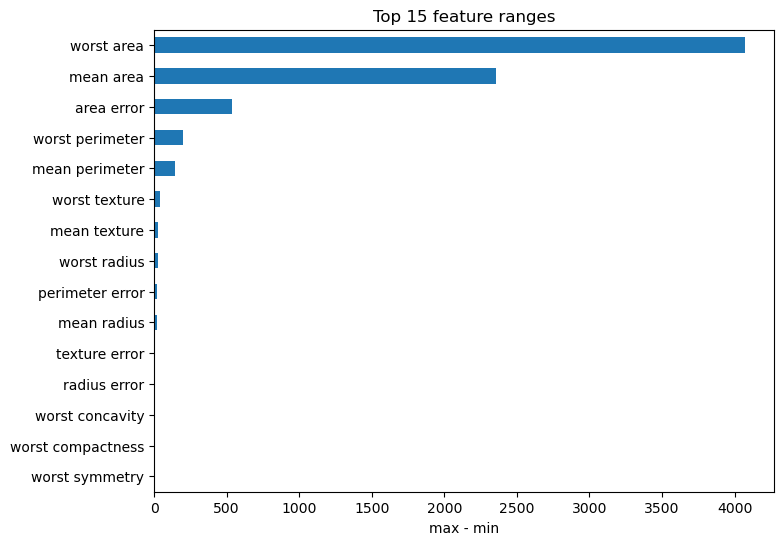

In [17]:
ax = feature_range.head(15).sort_values().plot(kind='barh', figsize=(8, 6), title='Top 15 feature ranges')
ax.set_xlabel('max - min')
plt.show()

## 9. 상관관계와 공분산 확인

강의자료의 `corr`, `cov` 개념과 연결됩니다.

PCA는 공분산 행렬 또는 상관 구조를 바탕으로 데이터가 가장 많이 퍼지는 방향을 찾습니다.

In [18]:
# 상관계수 행렬
corr_matrix = X.corr()
corr_matrix.iloc[:8, :8]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
mean radius,1.0000,0.3238,0.9979,0.9874,0.1706,0.5061,0.6768,0.8225
mean texture,0.3238,1.0000,0.3295,0.3211,-0.0234,0.2367,0.3024,0.2935
mean perimeter,0.9979,0.3295,1.0000,0.9865,0.2073,0.5569,0.7161,0.8510
mean area,0.9874,0.3211,0.9865,1.0000,0.1770,0.4985,0.6860,0.8233
mean smoothness,0.1706,-0.0234,0.2073,0.1770,1.0000,0.6591,0.5220,0.5537
mean compactness,0.5061,0.2367,0.5569,0.4985,0.6591,1.0000,0.8831,0.8311
mean concavity,0.6768,0.3024,0.7161,0.6860,0.5220,0.8831,1.0000,0.9214
mean concave points,0.8225,0.2935,0.8510,0.8233,0.5537,0.8311,0.9214,1.0000


In [19]:
# mean radius와 상관관계가 높은 변수 확인
corr_with_radius = corr_matrix['mean radius'].sort_values(ascending=False)
corr_with_radius.head(10)

mean radius            1.0000
mean perimeter         0.9979
mean area              0.9874
worst radius           0.9695
worst perimeter        0.9651
worst area             0.9411
mean concave points    0.8225
worst concave points   0.7442
area error             0.7359
radius error           0.6791
Name: mean radius, dtype: float64

In [20]:
# 공분산 행렬 일부 확인
cov_matrix = X.cov()
cov_matrix.iloc[:8, :8]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
mean radius,12.4189,4.9076,85.4471,1224.4834,0.0085,0.0942,0.1901,0.1125
mean texture,4.9076,18.4989,34.4398,485.9938,-0.0014,0.0538,0.1037,0.0490
mean perimeter,85.4471,34.4398,590.4405,8435.7723,0.0708,0.7147,1.3872,0.8024
mean area,1224.4834,485.9938,8435.7723,123843.5543,0.8762,9.2649,19.2449,11.2420
mean smoothness,0.0085,-0.0014,0.0708,0.8762,0.0002,0.0005,0.0006,0.0003
mean compactness,0.0942,0.0538,0.7147,9.2649,0.0005,0.0028,0.0037,0.0017
mean concavity,0.1901,0.1037,1.3872,19.2449,0.0006,0.0037,0.0064,0.0029
mean concave points,0.1125,0.0490,0.8024,11.2420,0.0003,0.0017,0.0029,0.0015


## 10. PCA 전 표준화

PCA는 분산이 큰 변수를 더 중요하게 볼 수 있습니다. 따라서 단위와 범위가 다른 특성들을 함께 사용할 때는 보통 표준화가 필요합니다.

표준화 공식은 다음과 같습니다.

\[
z = \frac{x - \mu}{\sigma}
\]

표준화 후 각 특성은 평균이 0, 표준편차가 1에 가까워집니다.

In [21]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols, index=X.index)
X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.0971,-2.0733,1.2699,0.9844,1.5685,3.2835,2.6529,2.5325,2.2175,2.2557,2.4897,-0.5653,2.8330,2.4876,-0.2140,1.3169,0.7240,0.6608,1.1488,0.9071,1.8867,-1.3593,2.3036,2.0012,1.3077,2.6167,2.1095,2.2961,2.7506,1.9370
1,1.8298,-0.3536,1.6860,1.9087,-0.8270,-0.4871,-0.0238,0.5481,0.0014,-0.8687,0.4993,-0.8762,0.2633,0.7424,-0.6054,-0.6929,-0.4408,0.2602,-0.8055,-0.0994,1.8059,-0.3692,1.5351,1.8905,-0.3756,-0.4304,-0.1467,1.0871,-0.2439,0.2812
2,1.5799,0.4562,1.5665,1.5589,0.9422,1.0529,1.3635,2.0372,0.9397,-0.3980,1.2287,-0.7801,0.8509,1.1813,-0.2970,0.8150,0.2131,1.4248,0.2370,0.2936,1.5119,-0.0240,1.3475,1.4563,0.5274,1.0829,0.8550,1.9550,1.1523,0.2014
3,-0.7689,0.2537,-0.5927,-0.7645,3.2836,3.4029,1.9159,1.4517,2.8674,4.9109,0.3264,-0.1104,0.2866,-0.2884,0.6897,2.7443,0.8195,1.1150,4.7327,2.0475,-0.2815,0.1340,-0.2499,-0.5500,3.3943,3.8934,1.9896,2.1758,6.0460,4.9350
4,1.7503,-1.1518,1.7766,1.8262,0.2804,0.5393,1.3710,1.4285,-0.0096,-0.5624,1.2705,-0.7902,1.2732,1.1904,1.4831,-0.0485,0.8285,1.1442,-0.3611,0.4993,1.2986,-1.4668,1.3385,1.2207,0.2206,-0.3134,0.6132,0.7293,-0.8684,-0.3971


In [22]:
standard_check = pd.DataFrame({
    'mean_after_scaling': X_scaled.mean(),
    'std_after_scaling': X_scaled.std(ddof=0),
})
standard_check.head(10)

,mean_after_scaling,std_after_scaling
mean radius,-0.0000,1.0000
mean texture,0.0000,1.0000
mean perimeter,-0.0000,1.0000
mean area,-0.0000,1.0000
mean smoothness,-0.0000,1.0000
mean compactness,0.0000,1.0000
mean concavity,0.0000,1.0000
mean concave points,-0.0000,1.0000
mean symmetry,0.0000,1.0000
mean fractal dimension,0.0000,1.0000


## 11. PCA로 2차원 축소

30개의 수치형 특성을 2개의 주성분으로 축소합니다.

- `PC1`: 첫 번째 주성분, 데이터 분산을 가장 많이 설명하는 방향
- `PC2`: 두 번째 주성분, PC1과 직교하면서 남은 분산을 가장 많이 설명하는 방향

In [23]:
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2_array = pca_2.fit_transform(X_scaled)

pca_2_df = pd.DataFrame(X_pca_2_array, columns=['PC1', 'PC2'], index=X.index)
pca_2_df['type'] = y.values

pca_2_df.head()

,PC1,PC2,type
0,9.1928,1.9486,malignant
1,2.3878,-3.7682,malignant
2,5.7339,-1.0752,malignant
3,7.1230,10.2756,malignant
4,3.9353,-1.9481,malignant


In [24]:
print('원본 X 크기:', X.shape)
print('PCA 2차원 변환 후 크기:', pca_2_df[['PC1', 'PC2']].shape)
print('PC1 설명분산비:', pca_2.explained_variance_ratio_[0])
print('PC2 설명분산비:', pca_2.explained_variance_ratio_[1])
print('PC1 + PC2 누적 설명분산비:', pca_2.explained_variance_ratio_.sum())

원본 X 크기: (569, 30)
PCA 2차원 변환 후 크기: (569, 2)
PC1 설명분산비: 0.44272025607526366
PC2 설명분산비: 0.1897118204403307
PC1 + PC2 누적 설명분산비: 0.6324320765155944


## 12. PCA 2차원 결과 시각화

PCA 결과를 산점도로 그리면 고차원 데이터에서 진단 유형이 어느 정도 분리되는지 직관적으로 확인할 수 있습니다.

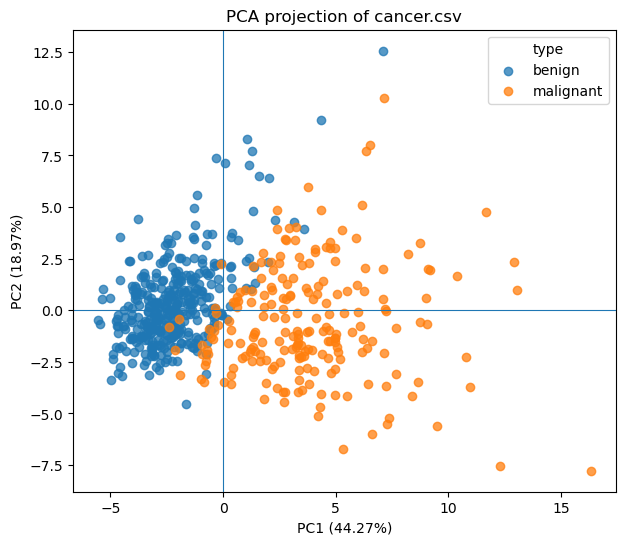

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

for label, group in pca_2_df.groupby('type'):
    ax.scatter(group['PC1'], group['PC2'], label=label, alpha=0.75)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title('PCA projection of cancer.csv')
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%})')
ax.legend(title='type')
plt.show()

### 해석 질문

1. `malignant`와 `benign`은 PC1, PC2 공간에서 어느 정도 분리되어 보이나요?
2. PC1 방향으로 이동할수록 어떤 진단 유형이 많이 나타나나요?
3. 2개의 주성분만으로 전체 정보의 몇 %를 설명하나요?

## 13. 주성분별 요약 통계

PCA 결과도 `DataFrame`이므로 `groupby`, `mean`, `std` 등을 사용할 수 있습니다.

In [26]:
pca_group_summary = pca_2_df.groupby('type')[['PC1', 'PC2']].agg(['mean', 'std', 'min', 'max'])
pca_group_summary

PC1                            PC2                       
             mean    std     min     max    mean    std     min     max
type                                                                   
benign    -2.2060 1.6423 -5.5657  7.0933  0.3463 2.0893 -4.5557 12.5732
malignant  3.7148 3.0277 -2.3859 16.3192 -0.5831 2.7273 -7.7759 10.2756

## 14. 전체 PCA와 설명분산비

2차원 축소는 시각화에는 유용하지만, 정보 손실이 있을 수 있습니다.

전체 주성분을 계산한 뒤, 각 주성분이 전체 분산을 얼마나 설명하는지 확인합니다.

In [27]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(feature_cols) + 1)],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
})
explained['cumulative_ratio'] = explained['explained_variance_ratio'].cumsum()

explained.head(10)

,PC,explained_variance_ratio,cumulative_ratio
0,PC1,0.4427,0.4427
1,PC2,0.1897,0.6324
2,PC3,0.0939,0.7264
3,PC4,0.0660,0.7924
4,PC5,0.0550,0.8473
5,PC6,0.0402,0.8876
6,PC7,0.0225,0.9101
7,PC8,0.0159,0.9260
8,PC9,0.0139,0.9399
9,PC10,0.0117,0.9516


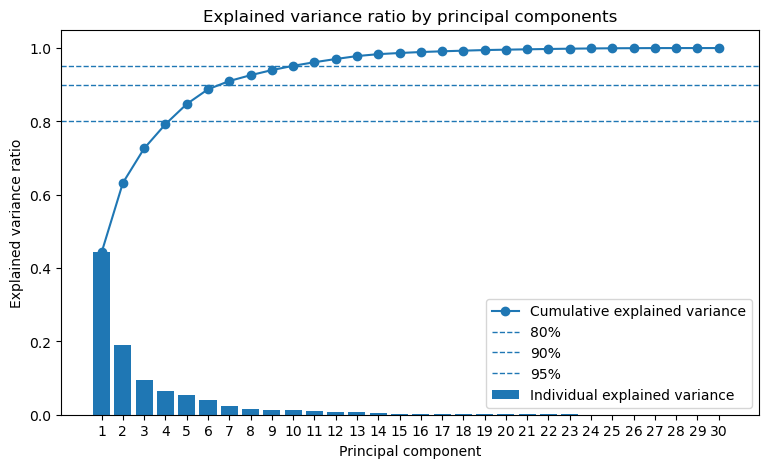

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

x_pos = np.arange(1, len(explained) + 1)
ax.bar(x_pos, explained['explained_variance_ratio'], label='Individual explained variance')
ax.plot(x_pos, explained['cumulative_ratio'], marker='o', label='Cumulative explained variance')
ax.axhline(0.80, linestyle='--', linewidth=1, label='80%')
ax.axhline(0.90, linestyle='--', linewidth=1, label='90%')
ax.axhline(0.95, linestyle='--', linewidth=1, label='95%')

ax.set_title('Explained variance ratio by principal components')
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.set_xticks(x_pos)
ax.legend()
plt.show()

In [29]:
thresholds = [0.80, 0.90, 0.95, 0.99]
for threshold in thresholds:
    n_components = int(np.argmax(explained['cumulative_ratio'].values >= threshold) + 1)
    print(f'{threshold:.0%} 이상 설명하려면 필요한 주성분 수: {n_components}개')

80% 이상 설명하려면 필요한 주성분 수: 5개
90% 이상 설명하려면 필요한 주성분 수: 7개
95% 이상 설명하려면 필요한 주성분 수: 10개
99% 이상 설명하려면 필요한 주성분 수: 17개


## 15. 주성분 로딩(loadings) 해석

PCA의 각 주성분은 원래 변수들의 선형 결합입니다.

`components_`를 이용하면 각 원래 특성이 PC1, PC2에 얼마나 기여하는지 확인할 수 있습니다.

> 절댓값이 클수록 해당 주성분을 구성하는 데 영향이 큰 변수로 볼 수 있습니다.

In [30]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_cols,
    columns=['PC1_loading', 'PC2_loading']
)

loadings.head(10)

,PC1_loading,PC2_loading
mean radius,0.2189,-0.2339
mean texture,0.1037,-0.0597
mean perimeter,0.2275,-0.2152
mean area,0.2210,-0.2311
mean smoothness,0.1426,0.1861
mean compactness,0.2393,0.1519
mean concavity,0.2584,0.0602
mean concave points,0.2609,-0.0348
mean symmetry,0.1382,0.1903
mean fractal dimension,0.0644,0.3666


In [31]:
top_pc1 = loadings['PC1_loading'].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings['PC2_loading'].abs().sort_values(ascending=False).head(10)

print('PC1 영향 상위 변수')
display(top_pc1.to_frame('abs_loading'))

print('PC2 영향 상위 변수')
display(top_pc2.to_frame('abs_loading'))

PC1 영향 상위 변수


,abs_loading
mean concave points,0.2609
mean concavity,0.2584
worst concave points,0.2509
mean compactness,0.2393
worst perimeter,0.2366
worst concavity,0.2288
worst radius,0.2280
mean perimeter,0.2275
worst area,0.2249
mean area,0.2210


PC2 영향 상위 변수


,abs_loading
mean fractal dimension,0.3666
fractal dimension error,0.2801
worst fractal dimension,0.2753
mean radius,0.2339
compactness error,0.2327
mean area,0.2311
worst radius,0.2199
worst area,0.2194
mean perimeter,0.2152
smoothness error,0.2044


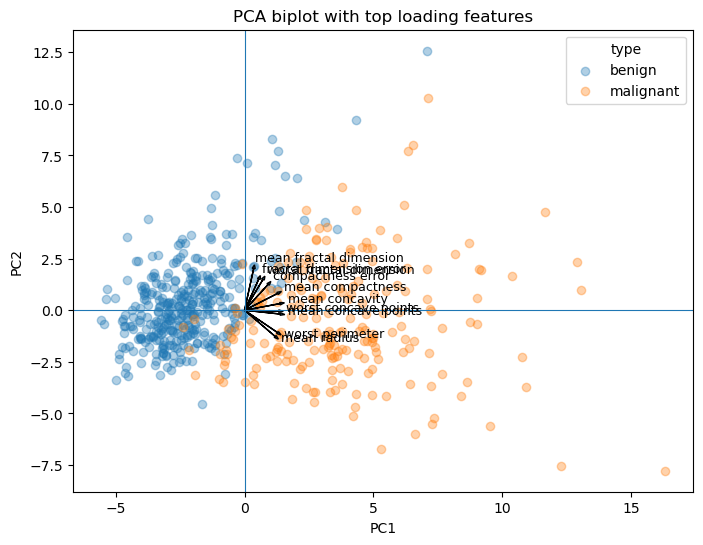

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

# 상위 변수만 간단한 biplot 형태로 표시
for label, group in pca_2_df.groupby('type'):
    ax.scatter(group['PC1'], group['PC2'], label=label, alpha=0.35)

top_features = sorted(set(top_pc1.index[:5]).union(set(top_pc2.index[:5])))
arrow_scale = 6

for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1_loading'] * arrow_scale
    y_loading = loadings.loc[feature, 'PC2_loading'] * arrow_scale
    ax.arrow(0, 0, x_loading, y_loading, head_width=0.12, length_includes_head=True)
    ax.text(x_loading * 1.08, y_loading * 1.08, feature, fontsize=9)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title('PCA biplot with top loading features')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='type')
plt.show()

## 16. 표준화하지 않은 PCA와 비교

아래 실습은 표준화 없이 PCA를 적용했을 때 결과가 어떻게 달라지는지 비교합니다.

스케일이 큰 변수들이 PCA 결과를 지배할 수 있다는 점을 확인합니다.

In [33]:
pca_2_unscaled = PCA(n_components=2, random_state=42)
X_pca_2_unscaled = pca_2_unscaled.fit_transform(X)

pca_2_unscaled_df = pd.DataFrame(X_pca_2_unscaled, columns=['PC1_unscaled', 'PC2_unscaled'])
pca_2_unscaled_df['type'] = y.values

print('표준화 PCA 설명분산비:', pca_2.explained_variance_ratio_)
print('비표준화 PCA 설명분산비:', pca_2_unscaled.explained_variance_ratio_)

pca_2_unscaled_df.head()

표준화 PCA 설명분산비: [0.44272026 0.18971182]
비표준화 PCA 설명분산비: [0.98204467 0.01617649]


,PC1_unscaled,PC2_unscaled,type
0,1160.1426,-293.9175,malignant
1,1269.1224,15.6302,malignant
2,995.7939,39.1567,malignant
3,-407.1808,-67.3803,malignant
4,930.3412,189.3407,malignant


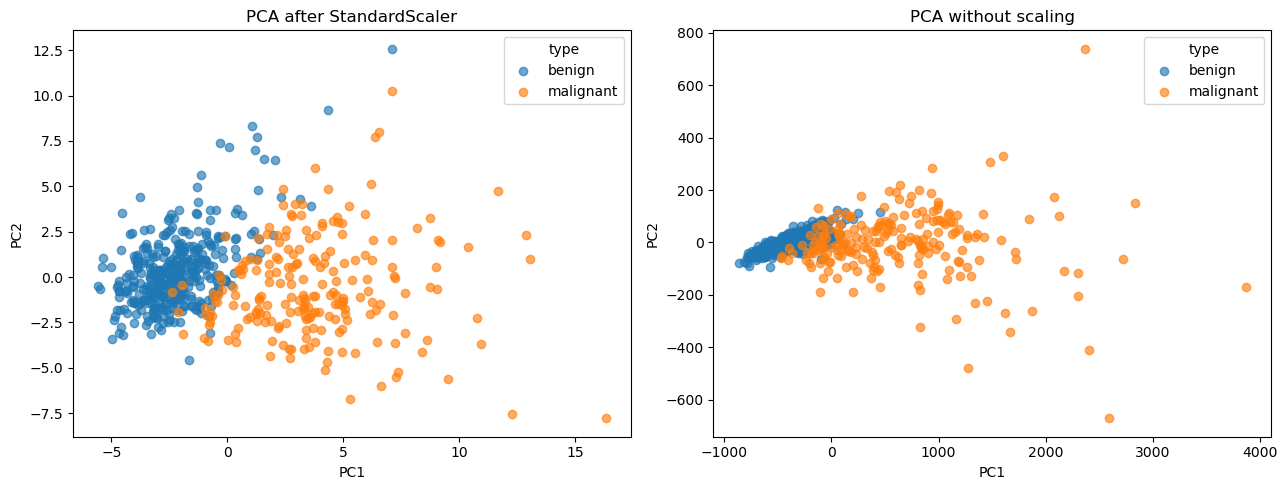

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, group in pca_2_df.groupby('type'):
    axes[0].scatter(group['PC1'], group['PC2'], label=label, alpha=0.65)
axes[0].set_title('PCA after StandardScaler')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='type')

for label, group in pca_2_unscaled_df.groupby('type'):
    axes[1].scatter(group['PC1_unscaled'], group['PC2_unscaled'], label=label, alpha=0.65)
axes[1].set_title('PCA without scaling')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='type')

plt.tight_layout()
plt.show()

## 17. PCA 차원 수에 따른 모델 성능 비교

PCA는 시각화뿐 아니라 모델 입력 차원을 줄이는 전처리로도 사용할 수 있습니다.

여기서는 로지스틱 회귀 모델을 기준으로 다음을 비교합니다.

1. 원본 30개 특성
2. PCA 2개 주성분
3. PCA 5개 주성분
4. PCA 누적 설명분산 95% 보존

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('훈련 데이터:', X_train.shape, y_train.shape)
print('시험 데이터:', X_test.shape, y_test.shape)

훈련 데이터: (426, 30) (426,)
시험 데이터: (143, 30) (143,)


In [36]:
models = {
    'Original 30 features': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'PCA 2 components': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2, random_state=42)),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'PCA 5 components': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=5, random_state=42)),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'PCA 95% variance': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42)),
        ('model', LogisticRegression(max_iter=5000))
    ]),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    n_components = model.named_steps.get('pca', None)
    n_components = n_components.n_components_ if n_components is not None and hasattr(n_components, 'n_components_') else X.shape[1]
    results.append({
        'model': name,
        'n_components': n_components,
        'train_accuracy': train_score,
        'test_accuracy': test_score,
    })

result_df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False)
result_df

,model,n_components,train_accuracy,test_accuracy
2,PCA 5 components,5,0.9718,0.9790
3,PCA 95% variance,10,0.9883,0.9720
0,Original 30 features,30,0.9883,0.9650
1,PCA 2 components,2,0.9507,0.9371


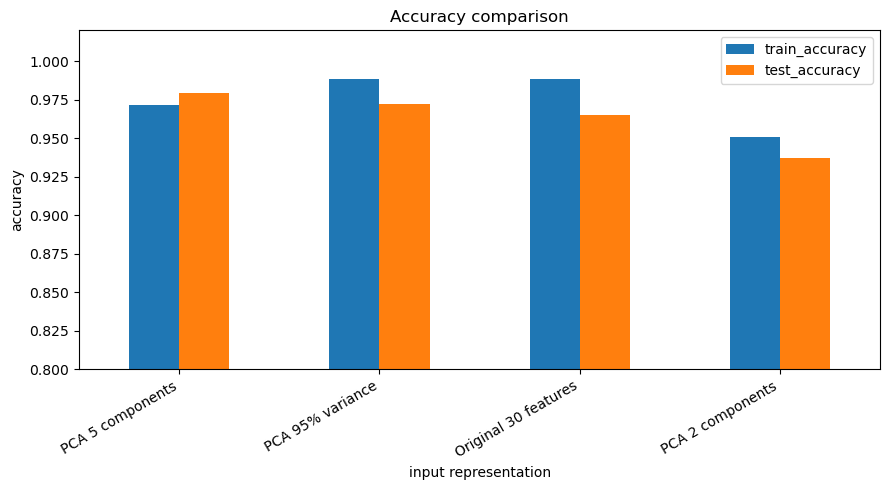

In [37]:
ax = result_df.set_index('model')[['train_accuracy', 'test_accuracy']].plot(
    kind='bar', figsize=(9, 5), ylim=(0.80, 1.02), title='Accuracy comparison'
)
ax.set_xlabel('input representation')
ax.set_ylabel('accuracy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 18. 교차검증으로 성능 비교

단일 train/test split 결과만 보면 우연성이 포함될 수 있습니다. 5-fold 교차검증으로 평균 성능을 확인합니다.

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    cv_results.append({
        'model': name,
        'cv_mean_accuracy': scores.mean(),
        'cv_std_accuracy': scores.std(),
        'fold_scores': np.round(scores, 4),
    })

cv_result_df = pd.DataFrame(cv_results).sort_values('cv_mean_accuracy', ascending=False)
cv_result_df

,model,cv_mean_accuracy,cv_std_accuracy,fold_scores
3,PCA 95% variance,0.9772,0.0070,"[0.9737, 0.9737, 0.9737, 0.9737, 0.9912]"
0,Original 30 features,0.9737,0.0166,"[0.9737, 0.9474, 0.9649, 0.9912, 0.9912]"
2,PCA 5 components,0.9631,0.0151,"[0.9561, 0.9474, 0.9649, 0.9561, 0.9912]"
1,PCA 2 components,0.9473,0.0241,"[0.9649, 0.9211, 0.9474, 0.9211, 0.9823]"


## 19. 혼동행렬과 분류 리포트

가장 성능이 좋은 모델을 선택하여 시험 데이터에서 혼동행렬과 분류 리포트를 확인합니다.

In [39]:
best_name = result_df.iloc[0]['model']
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print('선택된 모델:', best_name)
print('시험 정확도:', accuracy_score(y_test, y_pred))
print('\n분류 리포트')
print(classification_report(y_test, y_pred))

선택된 모델: PCA 5 components
시험 정확도: 0.9790209790209791

분류 리포트
              precision    recall  f1-score   support

      benign       0.98      0.99      0.98        90
   malignant       0.98      0.96      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



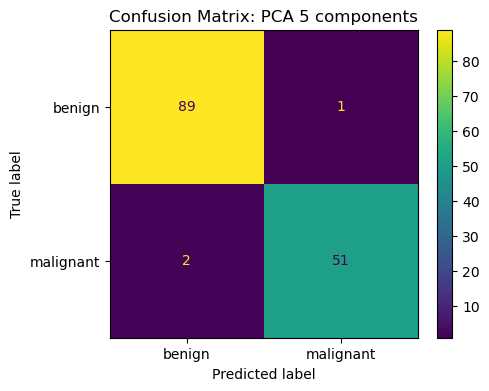

In [40]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax)
ax.set_title(f'Confusion Matrix: {best_name}')
plt.show()

## 20. PCA 결과 저장

실무에서는 PCA 결과를 별도 파일로 저장한 뒤, 시각화나 모델링 데이터로 재사용할 수 있습니다.

In [41]:
output_file = Path('cancer_pca_result.csv')
pca_2_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print('저장 완료:', output_file.resolve())
pd.read_csv(output_file).head()

저장 완료: C:\Users\user\student\3day\cancer_pca_result.csv


,PC1,PC2,type
0,9.1928,1.9486,malignant
1,2.3878,-3.7682,malignant
2,5.7339,-1.0752,malignant
3,7.1230,10.2756,malignant
4,3.9353,-1.9481,malignant


## 21. 추가 실습 문제

아래 셀들은 수업 중 직접 수정하며 실습할 수 있도록 구성했습니다.

### 문제 1
PCA 차원을 3개로 줄이고, `PC1`, `PC2`, `PC3` 컬럼을 가진 DataFrame을 만들어보세요.

### 문제 2
누적 설명분산비가 90% 이상이 되도록 PCA 차원 수를 자동으로 선택해보세요.

### 문제 3
`KNeighborsClassifier`를 사용하여 원본 데이터와 PCA 데이터의 성능을 비교해보세요.

### 문제 4
PC1에 가장 크게 기여하는 변수 5개와 PC2에 가장 크게 기여하는 변수 5개를 해석해보세요.

In [42]:
# 문제 1 예시 코드: PCA 3차원
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)

pca_3_df = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_3_df['type'] = y.values

print('PCA 3차원 설명분산비:', pca_3.explained_variance_ratio_)
print('누적 설명분산비:', pca_3.explained_variance_ratio_.sum())
pca_3_df.head()

PCA 3차원 설명분산비: [0.44272026 0.18971182 0.09393163]
누적 설명분산비: 0.7263637090899083


,PC1,PC2,PC3,type
0,9.1928,1.9486,-1.1232,malignant
1,2.3878,-3.7682,-0.5293,malignant
2,5.7339,-1.0752,-0.5517,malignant
3,7.1230,10.2756,-3.2328,malignant
4,3.9353,-1.9481,1.3898,malignant


In [43]:
# 문제 2 예시 코드: 누적 설명분산비 90% 이상
pca_90 = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_pca_90 = pca_90.fit_transform(X_scaled)

print('90% 이상 설명하기 위해 선택된 주성분 수:', pca_90.n_components_)
print('실제 누적 설명분산비:', pca_90.explained_variance_ratio_.sum())

90% 이상 설명하기 위해 선택된 주성분 수: 7
실제 누적 설명분산비: 0.9100953006967307


In [44]:
# 문제 3 예시 코드: KNN 모델 비교
knn_models = {
    'KNN original': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'KNN PCA 2': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2, random_state=42)),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'KNN PCA 95%': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42)),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
}

knn_result = []
for name, model in knn_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    knn_result.append({
        'model': name,
        'cv_mean_accuracy': scores.mean(),
        'cv_std_accuracy': scores.std(),
    })

pd.DataFrame(knn_result).sort_values('cv_mean_accuracy', ascending=False)

,model,cv_mean_accuracy,cv_std_accuracy
2,KNN PCA 95%,0.9631,0.0140
0,KNN original,0.9631,0.0179
1,KNN PCA 2,0.9315,0.0210


In [45]:
# 문제 4 예시 코드: PC1, PC2 기여 변수 확인
loading_summary = pd.DataFrame({
    'PC1_loading': loadings['PC1_loading'],
    'PC1_abs': loadings['PC1_loading'].abs(),
    'PC2_loading': loadings['PC2_loading'],
    'PC2_abs': loadings['PC2_loading'].abs(),
})

print('PC1 상위 5개 변수')
display(loading_summary.sort_values('PC1_abs', ascending=False).head(5))

print('PC2 상위 5개 변수')
display(loading_summary.sort_values('PC2_abs', ascending=False).head(5))

PC1 상위 5개 변수


,PC1_loading,PC1_abs,PC2_loading,PC2_abs
mean concave points,0.2609,0.2609,-0.0348,0.0348
mean concavity,0.2584,0.2584,0.0602,0.0602
worst concave points,0.2509,0.2509,-0.0083,0.0083
mean compactness,0.2393,0.2393,0.1519,0.1519
worst perimeter,0.2366,0.2366,-0.1999,0.1999


PC2 상위 5개 변수


,PC1_loading,PC1_abs,PC2_loading,PC2_abs
mean fractal dimension,0.0644,0.0644,0.3666,0.3666
fractal dimension error,0.1026,0.1026,0.2801,0.2801
worst fractal dimension,0.1318,0.1318,0.2753,0.2753
mean radius,0.2189,0.2189,-0.2339,0.2339
compactness error,0.1704,0.1704,0.2327,0.2327


## 22. 정리

이번 실습에서 확인한 핵심은 다음과 같습니다.

1. PCA는 고차원 수치형 데이터를 저차원으로 줄이는 대표적인 차원 축소 방법입니다.
2. `cancer.csv`는 30개의 수치형 특성을 가지므로 PCA 실습에 적합합니다.
3. PCA 전에는 변수별 스케일 차이를 줄이기 위해 표준화를 수행하는 것이 일반적입니다.
4. 2차원 PCA는 시각화에 유용하지만, 모델 성능을 위해서는 더 많은 주성분이 필요할 수 있습니다.
5. 설명분산비와 누적 설명분산비를 이용하면 정보 보존 수준에 따른 차원 수를 선택할 수 있습니다.
6. 주성분 로딩을 확인하면 각 주성분이 어떤 원래 변수들과 관련이 큰지 해석할 수 있습니다.

> 다음 단계로는 PCA 결과를 사용한 군집화, 분류 모델 최적화, t-SNE/UMAP 같은 비선형 차원 축소와의 비교를 진행할 수 있습니다.